# Finite-size scaling of empirical vs. mean-field $\mu_c$

For each disorder strength $\sigma$, degree distribution (exponential, regular),
system size $N$, and mean degree $C$, this measures the empirical critical point
$\mu_c^{\mathrm{emp}}$ as the zero-crossing of the shape scalar $c(\mu)$
(`glv.find_mu_c_shape_scalar`), averaged over several graph + disorder
realizations, and compares it to the $C$-independent mean-field value
$\mu_c^{\mathrm{th}}$. The reported quantity is the **relative distance**
$(\mu_c^{\mathrm{emp}} - \mu_c^{\mathrm{th}})/\mu_c^{\mathrm{th}}$, which puts the
exponential and regular graphs on the same footing.

Rows of the figure are disorder strengths $\sigma$; columns are graph types. Set
`MODE = "full"` to run the whole grid; `"validate"` runs a tiny subset.

In [1]:
import json
import os
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from collections import defaultdict
import glv

# Default matplotlib style (tab10 color cycle) -- the N curves come out in
# distinct, saturated colors rather than the muted editorial palette.

In [2]:
# --- Parameters ---
SIGMA_VALUES = [0.0, 0.2, 0.4]                # disorder strengths (figure rows)
GRAPH_TYPES  = ["exponential", "regular"]     # figure columns
N_VALUES     = [1000, 2000, 5000]             # system sizes (curves per panel)
C_VALUES     = [5, 10, 25, 50, 75, 100, 150]  # mean degrees (x-axis)
N_GRAPHS     = 10                             # realizations averaged per point
TAU_MAX      = 1e4                            # shape scalar c is converged by here
N_MU         = 21                             # mu grid points per realization
MU_WINDOW    = {"exponential": (-0.15, 0.50), # mu-grid offsets around mu_th,
                "regular":     (-0.20, 0.25)} #   wider for the heterogeneous graph

MODE = "full"   # "validate" -> tiny grid to check it runs; "full" -> the whole study

if MODE == "validate":
    SIGMA_VALUES = [0.2]
    N_VALUES     = [1000]
    C_VALUES     = [10, 50]
    N_GRAPHS     = 2
    N_MU         = 15

n_fits = (len(SIGMA_VALUES) * len(GRAPH_TYPES) * len(N_VALUES)
          * len(C_VALUES) * N_GRAPHS)
print(f"MODE={MODE}: {len(SIGMA_VALUES)} sigma x {len(GRAPH_TYPES)} types x "
      f"{len(N_VALUES)} N x {len(C_VALUES)} C x {N_GRAPHS} reps = {n_fits} fits")

MODE=full: 3 sigma x 2 types x 3 N x 7 C x 10 reps = 1260 fits


In [3]:
nu_exp = lambda g: np.exp(-g)

def theoretical_mu_c(graph_type, sigma):
    """C-independent mean-field mu_c for each degree distribution."""
    if graph_type == "exponential":
        return glv.calculate_mu_c(sigma=sigma, gamma=0.0, nu_pdf=nu_exp)["mu_c"]
    return glv.calculate_mu_c_regular(sigma)

def build_adjacency(graph_type, N, C, seed):
    """Binary adjacency (sparse csr) for one realization."""
    rng = np.random.default_rng(seed)
    if graph_type == "exponential":
        degs = np.maximum(1, np.round(rng.exponential(C, N))).astype(int)
        if degs.sum() % 2:
            degs[0] += 1
        G = nx.Graph(nx.configuration_model(list(degs), seed=int(rng.integers(2**31))))
        G.remove_edges_from(nx.selfloop_edges(G))
    else:  # regular: every node at degree C (requires N*C even)
        G = nx.random_regular_graph(C, N, seed=int(rng.integers(2**31)))
    return nx.to_scipy_sparse_array(G, format="csr", dtype=float)

# Theoretical value + mu-grid per (sigma, graph type); mu_c is C-independent.
MU_TH, MU_GRID = {}, {}
for s in SIGMA_VALUES:
    for gt in GRAPH_TYPES:
        mth = theoretical_mu_c(gt, s)
        lo, hi = MU_WINDOW[gt]
        MU_TH[(s, gt)] = mth
        MU_GRID[(s, gt)] = np.linspace(mth + lo, mth + hi, N_MU)
        print(f"sigma={s}  {gt:>11}: mu_th={mth:.4f}  "
              f"grid [{MU_GRID[(s, gt)][0]:.3f}, {MU_GRID[(s, gt)][-1]:.3f}]")

sigma=0.0  exponential: mu_th=0.5000  grid [0.350, 1.000]
sigma=0.0      regular: mu_th=1.0000  grid [0.800, 1.250]
sigma=0.2  exponential: mu_th=0.4990  grid [0.349, 0.999]
sigma=0.2      regular: mu_th=1.0000  grid [0.800, 1.250]
sigma=0.4  exponential: mu_th=0.4768  grid [0.327, 0.977]
sigma=0.4      regular: mu_th=0.9984  grid [0.798, 1.248]


In [4]:
def relative_gap(graph_type, N, C, sigma, seed):
    """One realization: empirical mu_c (shape-scalar zero-crossing) vs theory,
    as the relative distance (mu_emp - mu_th) / mu_th. None if no crossing."""
    A = build_adjacency(graph_type, N, C, seed)
    res = glv.find_mu_c_shape_scalar(
        A, C=C, sigma=sigma, mus=MU_GRID[(sigma, graph_type)], tau_max=TAU_MAX,
        seed=seed + 7_000_000,
    )
    mu_emp = res["mu_c"]
    if not np.isfinite(mu_emp):
        return None
    mth = MU_TH[(sigma, graph_type)]
    return (mu_emp - mth) / mth

# Cache results to disk so re-plotting / restyling never recomputes the grid.
# Delete mu_c_finite_size_results.json (or change the grid) to force a recompute.
CACHE_FILE = "mu_c_finite_size_results.json"
grid_key = json.dumps({
    "sigma": SIGMA_VALUES, "types": GRAPH_TYPES, "N": N_VALUES, "C": C_VALUES,
    "ngraphs": N_GRAPHS, "tau": TAU_MAX, "nmu": N_MU,
    "win": {k: list(v) for k, v in MU_WINDOW.items()},
}, sort_keys=True)

_cache = json.load(open(CACHE_FILE)) if os.path.exists(CACHE_FILE) else {}
if _cache.get("key") == grid_key:
    acc = defaultdict(list)
    for rec in _cache["records"]:
        acc[(rec["sigma"], rec["type"], rec["N"], rec["C"])] = rec["gaps"]
    print(f"loaded {sum(len(v) for v in acc.values())} cached fits")
else:
    # Deterministic, distinct seed per (sigma, type, N, C, realization).
    jobs, meta = [], []
    for si, s in enumerate(SIGMA_VALUES):
        for gi, gt in enumerate(GRAPH_TYPES):
            for ni, N in enumerate(N_VALUES):
                for ci, C in enumerate(C_VALUES):
                    for r in range(N_GRAPHS):
                        seed = (((((si * 53 + gi) * 97 + ni) * 101 + ci) * 1009 + r))
                        jobs.append(delayed(relative_gap)(gt, N, C, s, seed))
                        meta.append((s, gt, N, C))
    print(f"running {len(jobs)} fits ...")
    raw = Parallel(n_jobs=-1, verbose=5)(jobs)
    acc = defaultdict(list)
    for (s, gt, N, C), val in zip(meta, raw):
        if val is not None:
            acc[(s, gt, N, C)].append(val)
    records = [{"sigma": s, "type": gt, "N": N, "C": C, "gaps": v}
               for (s, gt, N, C), v in acc.items()]
    json.dump({"key": grid_key, "records": records}, open(CACHE_FILE, "w"))
    print(f"computed and cached {sum(len(v) for v in acc.values())} fits")

loaded 1260 cached fits


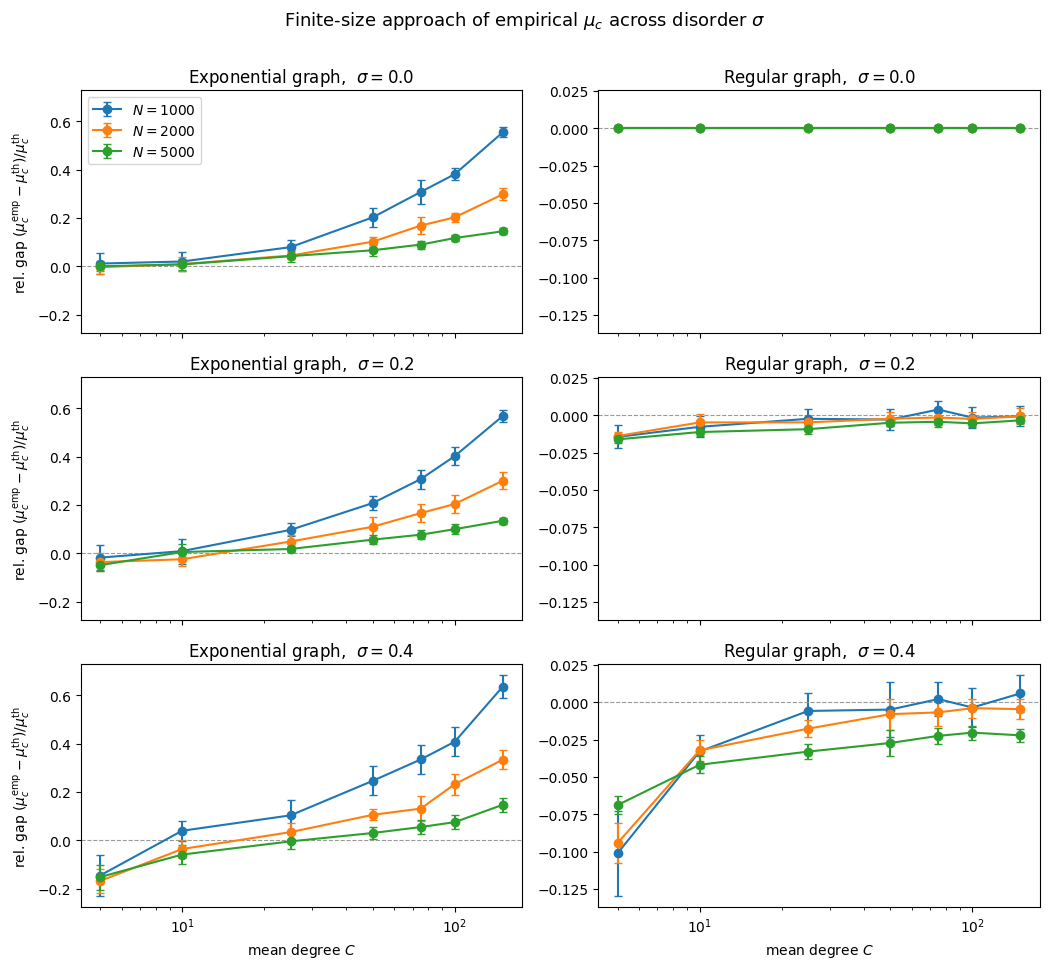

In [5]:
nrows, ncols = len(SIGMA_VALUES), len(GRAPH_TYPES)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.3 * ncols, 3.2 * nrows),
                         sharex=True, sharey="col", squeeze=False)

for si, s in enumerate(SIGMA_VALUES):
    for gi, gt in enumerate(GRAPH_TYPES):
        ax = axes[si][gi]
        for N in N_VALUES:
            Cs, means, stds = [], [], []
            for C in C_VALUES:
                vals = acc.get((s, gt, N, C), [])
                if vals:
                    Cs.append(C)
                    means.append(np.mean(vals))
                    stds.append(np.std(vals))
            if Cs:
                ax.errorbar(Cs, means, yerr=stds, marker="o", capsize=3,
                            lw=1.5, label=f"$N = {N}$")
        ax.axhline(0.0, color="0.6", lw=0.8, ls="--")
        ax.set_xscale("log")
        ax.set_xlim(min(C_VALUES) * 0.85, max(C_VALUES) * 1.18)  # hug the data
        ax.set_title(fr"{gt.capitalize()} graph,  $\sigma = {s}$")
        if si == nrows - 1:
            ax.set_xlabel(r"mean degree $C$")
        if gi == 0:
            ax.set_ylabel(
                r"rel. gap $(\mu_c^{\mathrm{emp}}-\mu_c^{\mathrm{th}})/\mu_c^{\mathrm{th}}$")

axes[0][0].legend()
fig.suptitle(r"Finite-size approach of empirical $\mu_c$ across disorder $\sigma$",
             y=1.005, fontsize=13)
fig.tight_layout()
fig.savefig("../thesis/mu_c_finite_size.png", bbox_inches="tight", dpi=150)
plt.show()